# Inteligencia Artificial (FP13) — Sesión 4
## Unidad 3 · Tuberías de aprendizaje automático
### 3.4 Segregación de datos · 3.5 Modelo de entrenamiento · Validación Cruzada

**Universidad Autónoma de Guadalajara** · *Notebook de trabajo*

---

**Objetivos de la sesión**

1. Comprender **por qué** y **cómo** se separan los datos antes de entrenar un modelo.
2. Dominar las **dos formas de segregación**: (1) Entrenamiento/Prueba y (2) Entrenamiento/Validación/Prueba.
3. Entender por qué **una sola división es frágil** y qué papel juega la **semilla aleatoria** (`random_state`).
4. Resolver esa fragilidad con **Validación Cruzada (K-Fold)** usando `cross_val_score`.
5. Distinguir **K-Fold tradicional** de **K-Fold Estratificado** y saber cuándo usar cada uno.
6. Interpretar la **media ± desviación estándar** como medida de desempeño y de **estabilidad**.

> **Dataset:** el mismo de la sesión pasada. Volvemos a **ingerir y consolidar las cuatro fuentes** de `Dataset_1/` (CSV, Excel, TXT y Parquet), tal como lo hicimos en 3.2.1–3.2.5, y hoy lo trabajaremos **completamente en unidades métricas (SI)**.

### ¿Dónde estamos en la tubería?

| Paso | Tema | Estado |
|---|---|---|
| 3.1 Definición del problema | Formular la pregunta | ✅ Sesión anterior |
| 3.2 Ingestión de datos | Cargar el dataset | ✅ Sesión anterior |
| 3.3 Preparación de datos | Limpiar / transformar | ✅ Sesión anterior |
| **3.4 Segregación de datos** | **Dividir en subconjuntos** | 🎯 **Hoy** |
| **3.5 Modelo de entrenamiento** | **Entrenar (mención)** | 🎯 **Hoy** |

Recordemos la idea central de la unidad: *cada paso produce una salida que se convierte en la entrada del siguiente*.
Hoy tomamos los datos ya preparados y los **segregamos correctamente** para poder evaluar un modelo de forma **honesta**.

**Regla que rige toda la sesión:**

> Un modelo solo demuestra que aprendió cuando acierta con datos que **nunca vio** durante el entrenamiento.

Si evaluamos con los mismos datos con los que el modelo aprendió, medimos su **memoria**, no su capacidad de **generalizar**.

In [2]:
# ===== BLOQUE 1 — Librerías y semilla global =====
# --- Librerías de la sesión --- 

import numpy as np 

import pandas as pd 

import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score 

from sklearn.linear_model import LogisticRegression 

from sklearn.tree import DecisionTreeClassifier 

from sklearn.neighbors import KNeighborsClassifier 

pd.set_option('display.max_columns', None) 

SEED = 42          # semilla fija -> resultados reproducibles 

np.random.seed(SEED) 

print('Librerías cargadas correctamente.') 

Librerías cargadas correctamente.


## 1. Ingestión y consolidación de las fuentes (repaso de 3.2.1–3.2.5)

Repetimos exactamente el procedimiento de la sesión pasada, pero **en una sola celda**: leemos las cuatro fuentes
del directorio `Dataset_1/` y las apilamos con `pd.concat`.

| Sección | Fuente | Archivo | Función |
|---|---|---|---|
| 3.2.1 | Flota de Norteamérica | `flota_norteamerica.csv` | `pd.read_csv` |
| 3.2.2 | Flota de Europa | `flota_europa.xlsx` (hoja `registros`) | `pd.read_excel` |
| 3.2.3 | Flota de Asia | `flota_asia.txt` (separador `~`) | `pd.read_csv(sep='~')` |
| 3.2.4 | Reingesta del data lake | `flota_datalake.parquet` | `pd.read_parquet` |
| 3.2.5 | **Consolidación** | — | `pd.concat(..., ignore_index=True)` |

> **Importante:** el notebook debe estar guardado en la **misma carpeta** que el directorio `Dataset_1/`, igual que
> en la sesión 3. Si el Excel o el Parquet marcan error, faltan librerías: `pip install openpyxl pyarrow`.

Recuerden lo que descubrimos al consolidar: el **data lake reingirió registros que ya estaban** en las otras tres
fuentes, así que el dataset consolidado trae **filas duplicadas**; y `horsepower` trae **valores faltantes**.
Las dos cosas se atienden en el bloque siguiente.

In [3]:
# ===== BLOQUE 2 — Ingestión y consolidación de las cuatro fuentes ===== 

# --- 3.2.1 · CSV: flota de Norteamérica --- 

df_csv = pd.read_csv('Dataset_1/flota_norteamerica.csv') 

print(f'CSV     -> {df_csv.shape}') 

# --- 3.2.2 · Excel: flota de Europa (hoja 'registros') --- 

df_xls = pd.read_excel('Dataset_1/flota_europa.xlsx', sheet_name='registros') 

print(f'Excel   -> {df_xls.shape}') 

# --- 3.2.3 · TXT delimitado con '~': flota de Asia --- 

df_txt = pd.read_csv('Dataset_1/flota_asia.txt', sep='~') 

print(f'TXT     -> {df_txt.shape}') 

# --- 3.2.4 · Parquet: reingesta del data lake --- 

df_pq = pd.read_parquet('Dataset_1/flota_datalake.parquet') 

print(f'Parquet -> {df_pq.shape}') 

# --- 3.2.5 · Consolidación de las cuatro fuentes --- 

df = pd.concat([df_csv, df_xls, df_txt, df_pq], ignore_index=True) 
print(f'\nDataset consolidado -> {df.shape}') 

print('Filas duplicadas:        ', df.duplicated().sum()) 
print('Faltantes en horsepower: ', df['horsepower'].isna().sum()) 

df.head(3) 



CSV     -> (249, 9)
Excel   -> (70, 9)
TXT     -> (79, 9)
Parquet -> (12, 9)

Dataset consolidado -> (410, 9)
Filas duplicadas:         12
Faltantes en horsepower:  6


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite


### 1.1 Limpieza del dataset consolidado

Cuatro decisiones. Las tres primeras ya las justificamos en 3.3; la segunda es consecuencia directa de haber
consolidado varias fuentes:

| Decisión | Motivo |
|---|---|
| Imputar los faltantes de `horsepower` con la **mediana** | La mediana no se ve arrastrada por valores extremos, a diferencia de la media |
| Eliminar los **duplicados** | El data lake reingirió registros que ya venían en el CSV, el Excel y el TXT |
| Eliminar la columna `name` | Es un **identificador único**: no aporta poder predictivo y sí ruido |
| Traducir `origin` (1, 2, 3) a **región** | Etiquetas legibles: EUA, Europa, Japón |

**Y un paso nuevo que hoy importa mucho.** Al apilar las fuentes una tras otra, el dataset quedó **agrupado por
región**: primero toda Norteamérica, después Europa, después Asia. Ese orden no es información, es un **artefacto
de cómo llegaron los archivos**. Si lo dejáramos tal cual y partiéramos el dataset por la mitad, el conjunto de
prueba quedaría formado casi por completo por vehículos asiáticos.

Por eso lo **ordenamos de forma canónica y lo barajamos con semilla fija**. Así la segregación no hereda el orden
de llegada de los archivos y, además, todo el grupo obtiene **exactamente los mismos resultados**.

In [4]:
# ===== BLOQUE 3 — Limpieza del dataset consolidado ===== 

# --- Limpieza (repaso de 3.3) --- 

# 1) Imputación de faltantes por mediana 

df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median()) 

# 2) Duplicados: el data lake reingirió registros ya presentes en otras fuentes 

print('Filas antes: ', len(df), '| duplicadas:', df.duplicated().sum()) 

df = df.drop_duplicates().reset_index(drop=True) 

print('Filas después:', len(df))  

# 3) El dataset quedó agrupado por región (las fuentes se apilaron una tras otra). 

#    Orden canónico + barajado con semilla fija -> mismos resultados para todos. 

df = df.sort_values(by=list(df.columns)) 

df = df.sample(frac=1, random_state=SEED).reset_index(drop=True) 

# 4) 'name' es un identificador único -> fuera 

df = df.drop(columns=['name']) 

# 5) origin: 1 = EUA, 2 = Europa, 3 = Japón 

df['origin'] = df['origin'].map({1: 'EUA', 2: 'Europa', 3: 'Japon'}) 

print('\nFaltantes restantes:', df.isnull().sum().sum()) 

print('Región:', df['origin'].value_counts().to_dict()) 

df.head() 

Filas antes:  410 | duplicadas: 12
Filas después: 398

Faltantes restantes: 0
Región: {'EUA': 249, 'Japon': 79, 'Europa': 70}


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,23.0,4,115.0,95.0,2694,15.0,75,Europa
1,44.6,4,91.0,67.0,1850,13.8,80,Japon
2,14.0,8,302.0,137.0,4042,14.5,73,EUA
3,23.5,6,173.0,110.0,2725,12.6,81,EUA
4,17.0,6,231.0,110.0,3907,21.0,75,EUA


## 2. Conversión a unidades métricas (SI)

El dataset original es estadounidense y está **en unidades imperiales**. Como ingenieros trabajamos en el
**Sistema Internacional**, así que convertimos las variables *antes* de cualquier otra cosa. Esto no es un capricho:

* Los resultados se pueden **interpretar y comunicar** en las unidades que usamos todos los días.
* Los **órdenes de magnitud se vuelven más homogéneos** (por ejemplo, el peso pasa de miles de libras a ~1 000–2 200 kg
  y la cilindrada de cientos de pulgadas³ a 1–7.5 L), lo que ayuda a que los algoritmos numéricos converjan mejor.
* Evitamos errores de interpretación en el umbral del problema.

### Factores de conversión

| Variable original | Unidad | Variable nueva | Unidad | Factor |
|---|---|---|---|---|
| `mpg` | millas por galón (US) | `rendimiento_km_l` | km/L | `× 0.4251437` |
| `displacement` | pulgadas³ | `cilindrada_l` | litros | `× 0.016387064` |
| `horsepower` | caballos de fuerza (hp) | `potencia_kw` | kilowatts | `× 0.745699872` |
| `weight` | libras | `peso_kg` | kilogramos | `× 0.45359237` |
| `acceleration` | segundos | `aceleracion_s` | segundos | *ya está en SI* |
| `cylinders`, `model_year`, `origin` | — | `cilindros`, `anio_modelo`, `origen` | — | *sin unidades* |

> Nota sobre `acceleration`: mide el **tiempo** que tarda el vehículo en pasar de 0 a 60 mph. El tiempo ya es una
> magnitud del SI (segundos), así que la variable no requiere conversión; solo la traducimos de nombre.

**Aprovechamos para renombrar todas las columnas en español.** Un dataset con nombres claros y unidades explícitas
es parte de la buena práctica de preparación de datos.

> **Continuidad con la sesión 3:** allá calculamos `consumo_L_100km = 235.215 / mpg` (litros por cada 100 km, donde
> *menos es mejor*). Hoy usamos `rendimiento_km_l` (kilómetros por litro, donde *más es mejor*) porque la variable
> objetivo se llama `alta_eficiencia` y conviene que las dos apunten en la misma dirección. Ambas son métricas y
> equivalentes: `rendimiento_km_l ≈ 100 / consumo_L_100km`.

In [5]:
# ===== BLOQUE 4 — Transformación de unidades imperiales a métricas ===== 

# --- Conversión a unidades métricas (SI) --- 

FACTOR_KM_L   = 0.4251437      # 1 mpg (US)   -> km/L 
FACTOR_LITROS = 0.016387064    # 1 pulgada^3  -> L 
FACTOR_KW     = 0.745699872    # 1 hp         -> kW 
FACTOR_KG     = 0.45359237     # 1 libra      -> kg 

datos = pd.DataFrame({ 
    'rendimiento_km_l': (df['mpg']*FACTOR_KM_L).round(2), 
    'cilindros': df['cylinders'], 
    'cilindrada_l': (df['displacement'] * FACTOR_LITROS).round(2), 
    'potencia_kw': (df['horsepower'] * FACTOR_KW).round(1), 
    'peso_kg': (df['weight'] * FACTOR_KG).round(0), 
    'aceleracion_s': df['acceleration'], 
    'anio_modelo': df['model_year'], 
    'origen': df['origin'],
    }) 

print('Forma tras la conversión:', datos.shape) 
datos.head() 


Forma tras la conversión: (398, 8)


,rendimiento_km_l,cilindros,cilindrada_l,potencia_kw,peso_kg,aceleracion_s,anio_modelo,origen
0,9.78,4,1.88,70.8,1222.0,15.0,75,Europa
1,18.96,4,1.49,50.0,839.0,13.8,80,Japon
2,5.95,8,4.95,102.2,1833.0,14.5,73,EUA
3,9.99,6,2.83,82.0,1236.0,12.6,81,EUA
4,7.23,6,3.79,82.0,1772.0,21.0,75,EUA


In [6]:
# ===== BLOQUE 5 — Verificación de la conversión y codificación one-hot ===== 
# Comprobamos que los rangos ya son métricos y razonables 
metricas = ['rendimiento_km_l', 'cilindrada_l', 'potencia_kw', 'peso_kg'] 
print(datos[metricas].describe().round(2)) 

# 'origen' es categórica -> one-hot (repaso de 3.3) 
datos = pd.get_dummies(datos, columns=['origen'], prefix='origen') 
print('\nColumnas finales:', list(datos.columns)) 



       rendimiento_km_l  cilindrada_l  potencia_kw  peso_kg
count            398.00        398.00       398.00   398.00
mean              10.00          3.17        77.78  1347.37
std                3.32          1.71        28.50   384.12
min                3.83          1.11        34.30   732.00
25%                7.44          1.70        56.70  1008.50
50%                9.78          2.43        69.70  1271.50
75%               12.33          4.29        93.20  1636.50
max               19.81          7.46       171.50  2331.00

Columnas finales: ['rendimiento_km_l', 'cilindros', 'cilindrada_l', 'potencia_kw', 'peso_kg', 'aceleracion_s', 'anio_modelo', 'origen_EUA', 'origen_Europa', 'origen_Japon']


## 3. Definición del problema de HOY (repaso de 3.1)

En 3.1 planteamos una pregunta general. Hoy la convertimos en un problema de **clasificación binaria** para poder
medir *accuracy* (porcentaje de aciertos):

> **¿Este vehículo es de alta eficiencia de combustible?**

Definimos la variable objetivo:

$$\text{alta\_eficiencia} = \begin{cases} 1 & \text{si } \text{rendimiento} \geq 12.3 \ \text{km/L} \\ 0 & \text{en caso contrario} \end{cases}$$

### ¿De dónde sale el umbral de 12.3 km/L?

En la literatura del dataset se suele usar el corte de **29 mpg** para separar a los vehículos más eficientes de su época.
Convertido: `29 × 0.4251437 = 12.33 km/L`. Redondeamos a **12.3 km/L**, un número limpio que además deja
**exactamente los mismos 105 vehículos** en la clase positiva. El umbral es una **decisión de diseño del problema**,
no un dato que venga en el archivo: debe justificarse y documentarse.

⚠️ **Punto clave — fuga de datos (*data leakage*):** el objetivo se **deriva** de `rendimiento_km_l`.
Por lo tanto **debemos eliminar `rendimiento_km_l` de las variables predictoras (X)**. Si lo dejáramos, el modelo
"haría trampa": obtendría 100 % de aciertos aplicando la misma regla del umbral, y nos engañaríamos por completo.
Es el mismo error que discutimos la sesión pasada.

In [7]:
# ===== BLOQUE 6 — Variable objetivo y distribución de clases ===== 
# --- Variable objetivo --- 
UMBRAL_KM_L = 12.3     # equivalente métrico de 29 mpg 
datos['alta_eficiencia'] = (datos['rendimiento_km_l'] >= UMBRAL_KM_L).astype(int)
 
print('Distribución de clases:') 
print(datos['alta_eficiencia'].value_counts()) 
print(f"\nProporción de clase positiva: {datos['alta_eficiencia'].mean():.1%}") 
print('\n>> Clases DESBALANCEADAS (~26% vs ~74%): recordarlo para la estratificación.') 



Distribución de clases:
alta_eficiencia
0    293
1    105
Name: count, dtype: int64

Proporción de clase positiva: 26.4%

>> Clases DESBALANCEADAS (~26% vs ~74%): recordarlo para la estratificación.


In [8]:
# ===== BLOQUE 7 — Separación de predictoras (X) y objetivo (y) ===== 
# --- X e y --- ¡eliminamos rendimiento_km_l de X para evitar la fuga de datos! 
X = datos.drop(columns=['rendimiento_km_l', 'alta_eficiencia']) 
y = datos['alta_eficiencia'] 
print('X (predictoras):', X.shape) 
for col in X.columns: 
    print('   -', col) 

print('y (objetivo):   ', y.shape) 



X (predictoras): (398, 9)
   - cilindros
   - cilindrada_l
   - potencia_kw
   - peso_kg
   - aceleracion_s
   - anio_modelo
   - origen_EUA
   - origen_Europa
   - origen_Japon
y (objetivo):    (398,)


---
# 3.4 · SEGREGACIÓN DE DATOS

> *"Para entrenar un modelo con los datos procesados, se recomienda dividir los datos en subconjuntos."*
> — Artasanchez & Joshi, Cap. 3

**Segregar** significa repartir las filas del dataset en subconjuntos con **roles distintos**. El libro describe
**dos maneras** de hacerlo; veremos ambas y, sobre todo, **cuándo usar cada una**.

## Enfoque (1): Entrenamiento + Prueba

El esquema más sencillo: dos subconjuntos.

| Subconjunto | Proporción típica | Rol | ¿El modelo lo ve al entrenar? |
|---|---|---|---|
| **Entrenamiento** (*train*) | 80 % | El modelo aprende de aquí | ✅ Sí |
| **Prueba** (*test*) | 20 % | Simula datos **nuevos**, nunca vistos | ❌ No |

Dos argumentos importantes de `train_test_split`:

* `stratify=y` → conserva la **proporción de clases** en ambos subconjuntos. Sin él, por azar podríamos dejar
  el conjunto de prueba con muy pocos vehículos eficientes y la medición perdería sentido.
* `random_state=SEED` → fija la **semilla aleatoria**. Volveremos a este argumento en un momento, porque es
  mucho más importante de lo que parece.

In [10]:
# ===== BLOQUE 8 — Enfoque (1): división 80/20 y primer modelo ===== 

# --- Enfoque (1): Entrenamiento + Prueba --- 

X_train, X_test, y_train, y_test = train_test_split( 
X, y, 
test_size=0.20,      # 20% para prueba 
stratify=y,          # conserva la proporción de clases 
random_state=SEED    # semilla fija -> división reproducible 
) 

print(f'Entrenamiento: {X_train.shape[0]} vehículos ({y_train.mean():.1%} positivos)') 
print(f'Prueba:        {X_test.shape[0]} vehículos ({y_test.mean():.1%} positivos)') 

# Modelo sencillo: hoy lo tratamos como CAJA NEGRA (lo estudiamos a fondo en las Unidades 5-6) 

modelo = LogisticRegression(max_iter=2000) 
modelo.fit(X_train, y_train)                 # aprende SOLO con entrenamiento 
acc_test = modelo.score(X_test, y_test)      # evalúa con datos NO vistos 

print(f'\nAccuracy sobre el conjunto de PRUEBA: {acc_test:.4f}') 

Entrenamiento: 318 vehículos (26.4% positivos)
Prueba:        80 vehículos (26.2% positivos)

Accuracy sobre el conjunto de PRUEBA: 0.9250


## El problema de una sola división: las semillas

`train_test_split` **reparte las filas al azar**. Ese azar no es realmente aleatorio: lo produce un generador de
números pseudoaleatorios que arranca desde un valor inicial llamado **semilla** (`random_state`).

* **Misma semilla → exactamente la misma división.** Por eso podemos reproducir resultados y por eso la fijamos.
* **Semilla distinta → otra división → otros 80 vehículos en la prueba → otro accuracy.**

Aquí está el punto incómodo: la semilla es **arbitraria**. Nadie nos obliga a usar 42. Si el resultado cambia
según un número que elegimos a capricho, entonces **ese resultado no es una propiedad del modelo**, sino del corte.

Probemos seis semillas distintas y veamos qué tanto se mueve el accuracy.

In [12]:
# ===== BLOQUE 9 — Efecto de la semilla sobre una sola división ===== 
# --- ¿Qué tanto cambia el resultado al cambiar la semilla? --- 
semillas = [0, 1, 7, 21, 42, 99] 
resultados = [] 

print('Accuracy de prueba según la semilla del corte:') 
for rs in semillas: 
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20, stratify=y, random_state=rs) 
m = LogisticRegression(max_iter=2000).fit(Xtr, ytr) 
a = m.score(Xte, yte) 
resultados.append(a) 
print(f'  random_state = {rs:>3}  ->  accuracy = {a:.4f}') 

resultados = np.array(resultados) 
print(f'\n>> El accuracy va de {resultados.min():.4f} a {resultados.max():.4f}: ' 
f'{(resultados.max()-resultados.min())*100:.1f} puntos porcentuales de diferencia,') 
print('>> SOLO por haber cambiado el número de la semilla. El modelo es el mismo.') 
print('>> ¿Cuál de los seis reportamos? Ninguno por sí solo es confiable.') 



Accuracy de prueba según la semilla del corte:
  random_state =  99  ->  accuracy = 0.9375

>> El accuracy va de 0.9375 a 0.9375: 0.0 puntos porcentuales de diferencia,
>> SOLO por haber cambiado el número de la semilla. El modelo es el mismo.
>> ¿Cuál de los seis reportamos? Ninguno por sí solo es confiable.


### Visualicemos la fragilidad

Una gráfica deja el argumento mucho más claro que una lista de números: si el resultado "salta" según la semilla,
elegir uno solo equivale a **elegir la respuesta que más nos conviene**.

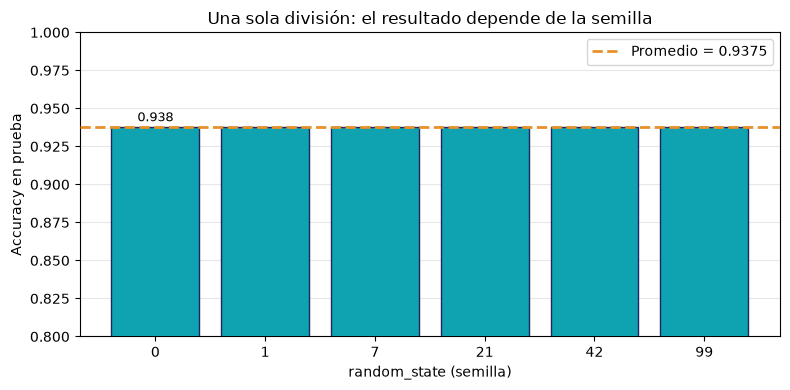

In [13]:
# ===== BLOQUE 10 — Gráfica: accuracy según la semilla ===== 
# --- Gráfica: la lotería de la semilla --- 
plt.figure(figsize=(8, 4)) 
plt.grid(axis='y', alpha=0.3, zorder=0) 
plt.bar([str(s) for s in semillas], resultados, color='#0FA3B1', edgecolor='#1E2664', zorder=3) 
plt.axhline(resultados.mean(), color='#E8912B', linestyle='--', linewidth=2, zorder=4, 
        label=f'Promedio = {resultados.mean():.4f}') 

for i, a in enumerate(resultados): 
    plt.text(i, a + 0.004, f'{a:.3f}', ha='center', fontsize=9) 

plt.ylim(0.80, 1.0) 
plt.xlabel('random_state (semilla)') 
plt.ylabel('Accuracy en prueba') 
plt.title('Una sola división: el resultado depende de la semilla') 
plt.legend() 
plt.tight_layout() 
plt.show() 

## Enfoque (2): Entrenamiento + Validación + Prueba

El enfoque (1) alcanza cuando solo queremos **una** estimación de desempeño. Pero en la práctica casi nunca
entrenamos un solo modelo: probamos varios algoritmos, ajustamos hiperparámetros, comparamos. Y ahí aparece un
problema nuevo.

**Si usamos el conjunto de prueba para elegir el mejor modelo, la prueba deja de ser "datos nunca vistos".**
Aunque el modelo no se haya entrenado con esas filas, *nosotros* las miramos para tomar una decisión. El
conocimiento de la prueba se filtró en el proceso a través de nuestras manos, y la estimación final queda inflada.

La solución es apartar un tercer subconjunto:

| Subconjunto | Proporción típica | Rol | ¿Cuántas veces se usa? |
|---|---|---|---|
| **Entrenamiento** | ~60 % | El modelo aprende | Muchas (una por modelo candidato) |
| **Validación** | ~20 % | Comparar modelos / afinar hiperparámetros | Muchas (una por modelo candidato) |
| **Prueba** | ~20 % | Evaluación **final** | **Una sola vez, al final** |

> **Regla de oro: la prueba es sagrada.** Se abre una vez, cuando ya no queda ninguna decisión por tomar.

Se construye en **dos pasos**: primero apartamos la prueba, y del resto sacamos la validación.
Ojo con el `test_size` del segundo paso: para que la validación sea el 20 % **del total**, debe ser el
**25 % del 80 % restante** (0.25 × 0.80 = 0.20).

In [14]:
# ===== BLOQUE 11 — Enfoque (2): división en tres subconjuntos ===== 
# --- Enfoque (2): Entrenamiento + Validación + Prueba --- 
# Paso 1: apartar la PRUEBA (20% del total) 
X_temp, X_test2, y_temp, y_test2 = train_test_split( 
    X, y, test_size=0.20, stratify=y, random_state=SEED) 

# Paso 2: del 80% restante, sacar VALIDACIÓN (25% de 80% = 20% del total) 
X_train2, X_val, y_train2, y_val = train_test_split( 
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=SEED) 

total = len(X) 
print(f'Entrenamiento: {len(X_train2):>3} vehículos ({len(X_train2)/total:.0%})') 
print(f'Validación:    {len(X_val):>3} vehículos ({len(X_val)/total:.0%})') 
print(f'Prueba:        {len(X_test2):>3} vehículos ({len(X_test2)/total:.0%})') 
print('   ^ la prueba queda INTOCABLE hasta el final') 



Entrenamiento: 238 vehículos (60%)
Validación:     80 vehículos (20%)
Prueba:         80 vehículos (20%)
   ^ la prueba queda INTOCABLE hasta el final


### El enfoque (2) en acción: elegir entre tres candidatos

Así se usa realmente. Entrenamos **tres** modelos con el conjunto de entrenamiento, los comparamos **en validación**,
elegimos al ganador, y **solo entonces** abrimos la prueba una única vez.

Fíjense en el detalle importante del resultado: el accuracy del ganador **en prueba** suele ser algo distinto
(y normalmente algo peor) que su accuracy **en validación**. Eso es exactamente lo que queríamos capturar: al haber
elegido al ganador mirando la validación, el número de validación quedó ligeramente optimista.

In [15]:
# ===== BLOQUE 12 — Uso del enfoque (2): selección de modelo en validación ===== 
# --- Comparar candidatos en VALIDACIÓN, decidir, y medir en PRUEBA una sola vez --- 
candidatos = { 
    'Regresión logística':      LogisticRegression(max_iter=2000), 
    'Árbol (profundidad 3)':    DecisionTreeClassifier(max_depth=3, random_state=SEED), 
    'Árbol (sin límite)':       DecisionTreeClassifier(random_state=SEED), 

}  

print('Accuracy en VALIDACIÓN (aquí SÍ podemos decidir):') 
mejor_nombre, mejor_modelo, mejor_acc = None, None, -1 
for nombre, m in candidatos.items(): 
    m.fit(X_train2, y_train2) 
    acc_val = m.score(X_val, y_val) 
    print(f'  {nombre:<24} -> {acc_val:.4f}') 
    if acc_val > mejor_acc: 
        mejor_nombre, mejor_modelo, mejor_acc = nombre, m, acc_val 

print(f'\nGanador: {mejor_nombre} (validación = {mejor_acc:.4f})') 

print(f'Accuracy del ganador en PRUEBA (evaluación final, una sola vez): ' 

    f'{mejor_modelo.score(X_test2, y_test2):.4f}') 

Accuracy en VALIDACIÓN (aquí SÍ podemos decidir):
  Regresión logística      -> 0.9500
  Árbol (profundidad 3)    -> 0.9125
  Árbol (sin límite)       -> 0.8875

Ganador: Regresión logística (validación = 0.9500)
Accuracy del ganador en PRUEBA (evaluación final, una sola vez): 0.9250


### ¿Dos partes o tres partes?

| | **(1) Train / Test** | **(2) Train / Validación / Test** |
|---|---|---|
| ¿Cuándo se usa? | Un solo modelo, sin decisiones que tomar | Hay que **comparar** modelos o **afinar** hiperparámetros |
| Datos para entrenar | Más (80 %) | Menos (60 %) |
| ¿Dónde se toman las decisiones? | No hay decisiones | En **validación** |
| Riesgo principal | El resultado depende del corte | Se desperdician datos si el dataset es pequeño |
| Con 398 filas… | Aceptable, pero frágil | **Caro**: solo ~239 filas para entrenar |

Y aquí está el problema de fondo que arrastran **los dos** enfoques: seguimos dependiendo de **un solo corte al azar**.
El enfoque (2) nos permitió decidir sin contaminar la prueba, pero su medición de validación sigue siendo tan
frágil como vimos en la gráfica anterior. Además, con un dataset chico, apartar 40 % de los datos duele.

**La validación cruzada resuelve las dos cosas a la vez.**

---
# VALIDACIÓN CRUZADA (*Cross-Validation*)

**Idea:** en lugar de confiar en **una** división, las rotamos todas.

1. Dividimos los datos en **K partes** del mismo tamaño, llamadas **folds** (pliegues).
2. Hacemos **K rondas**. En cada ronda: un fold se usa para **evaluar** y los otros K−1 para **entrenar**.
3. Obtenemos **K mediciones** de accuracy y reportamos su **media** y su **desviación estándar**.

Con K = 5, cada fold tiene ~80 vehículos y **cada dato del dataset se usa para evaluar exactamente una vez**
y para entrenar exactamente K−1 veces.

| Ronda | Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5 |
|---|---|---|---|---|---|
| 1 | 🔴 evalúa | entrena | entrena | entrena | entrena |
| 2 | entrena | 🔴 evalúa | entrena | entrena | entrena |
| 3 | entrena | entrena | 🔴 evalúa | entrena | entrena |
| 4 | entrena | entrena | entrena | 🔴 evalúa | entrena |
| 5 | entrena | entrena | entrena | entrena | 🔴 evalúa |

**Ventajas:**

* Estimación **más robusta**: promedio de K mediciones en vez de una sola.
* **Aprovecha todos los datos** — clave con datasets pequeños como el nuestro (¡solo 398 filas!).
* La **desviación estándar** nos dice qué tan **estable** es el modelo frente al azar del corte.

**Costo:** entrenar K veces en lugar de una. Con 398 filas es instantáneo; con millones de filas hay que pensarlo.

`scikit-learn` lo hace todo en una sola línea con **`cross_val_score`**: recibe el modelo, los datos y la estrategia
de división (`cv`), y devuelve el arreglo con los K accuracies.

In [17]:
# ===== BLOQUE 13 — Validación cruzada con cross_val_score (K-Fold, K=5) ===== 
# --- Validación cruzada en una línea --- 
kfold = KFold(n_splits=5, shuffle=True, random_state=SEED) 
scores = cross_val_score(LogisticRegression(max_iter=2000), X, y, cv=kfold) 
print('Accuracy por fold:', np.round(scores, 4)) 
print(f'\nMedia:               {scores.mean():.4f}') 
print(f'Desviación estándar: {scores.std():.4f}') 
print(f'\n>> Se reporta como:  {scores.mean():.4f} ± {scores.std():.4f}') 



Accuracy por fold: [0.95   0.925  0.9125 0.9494 0.9367]

Media:               0.9347
Desviación estándar: 0.0144

>> Se reporta como:  0.9347 ± 0.0144


### Cómo se lee "media ± desviación estándar"

* La **media** estima el desempeño que esperamos en datos nuevos. Es una estimación **mucho más confiable** que la
  de una sola división, porque promedia K mediciones independientes.
* La **desviación estándar** mide la **estabilidad**. Si es pequeña, el modelo se comporta parecido sin importar qué
  datos le tocaron; si es grande, su desempeño depende demasiado del azar y **no podemos confiar en la media**.

Un modelo con `0.94 ± 0.03` es preferible a uno con `0.95 ± 0.12`: el segundo puede rendir 0.83 el día que lo
pongamos en producción.

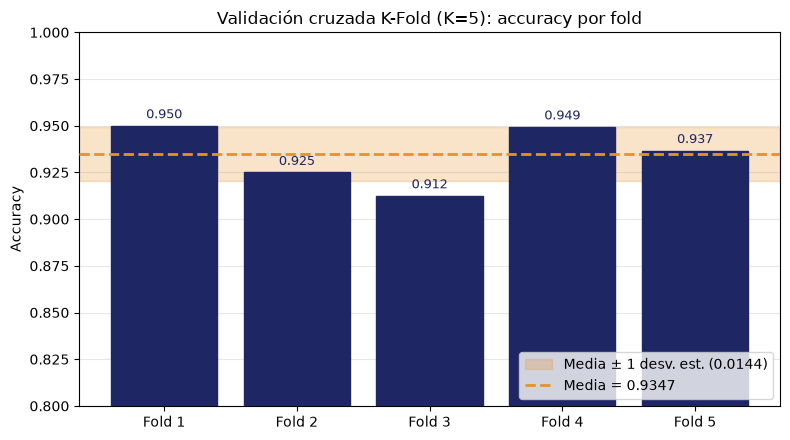

In [18]:
# ===== BLOQUE 14 — Gráfica: accuracy por fold ===== 
# --- Gráfica: accuracy por fold --- 
folds = [f'Fold {i}' for i in range(1, len(scores) + 1)] 
media = scores.mean() 
desv  = scores.std() 

plt.figure(figsize=(8, 4.5)) 
plt.grid(axis='y', alpha=0.3, zorder=0) 

# Banda de media ± 1 desviación estándar (queda DETRÁS de las barras) 
plt.axhspan(media - desv, media + desv, color='#E8912B', alpha=0.25, zorder=1, 
        label=f'Media ± 1 desv. est. ({desv:.4f})') 
plt.bar(folds, scores, color='#1E2664', edgecolor='#1E2664', zorder=3) 
plt.axhline(media, color='#E8912B', linestyle='--', linewidth=2, zorder=4, 
        label=f'Media = {media:.4f}') 

for i, a in enumerate(scores): 
    plt.text(i, a + 0.004, f'{a:.3f}', ha='center', color='#1E2664', fontsize=9, zorder=5) 

plt.ylim(0.80, 1.0) 
plt.ylabel('Accuracy') 
plt.title('Validación cruzada K-Fold (K=5): accuracy por fold') 
plt.legend(loc='lower right') 
plt.tight_layout() 
plt.show() 

## K-Fold **Estratificado**: cuando las clases están desbalanceadas

Nuestro objetivo tiene **~26 % de positivos**. `KFold` reparte las filas al azar **sin mirar la clase**, así que por
pura suerte un fold puede quedar con 21 % de vehículos eficientes y otro con 31 %. Cuando eso pasa, la diferencia de
accuracy entre folds **no mide al modelo**: mide qué tan afortunado fue el reparto.

**`StratifiedKFold`** garantiza que **cada fold conserve la proporción original de clases**. Comparemos ambos
directamente mirando la proporción de positivos que le tocó a cada fold.

In [ ]:
# ===== BLOQUE 15 — K-Fold normal vs. estratificado: proporción de clase por fold ===== 
# --- ¿Qué proporción de positivos le toca a cada fold? --- 
kf_normal = KFold(n_splits=5, shuffle=True, random_state=SEED) 
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED) 

prop_normal = [y.iloc[val].mean() for _, val in kf_normal.split(X)] 
prop_strat  = [y.iloc[val].mean() for _, val in skf.split(X, y)] 

print(f'Proporción REAL de positivos en el dataset: {y.mean():.3f}\n') 
print('Proporción de positivos por fold:') 
print('  K-Fold normal      :', [f'{p:.3f}' for p in prop_normal]) 
print('  Stratified K-Fold  :', [f'{p:.3f}' for p in prop_strat]) 
print(f'\n  Rango normal      : {min(prop_normal):.3f} a {max(prop_normal):.3f}  <- oscila') 
print(f'  Rango estratificado: {min(prop_strat):.3f} a {max(prop_strat):.3f}  <- se mantiene') 

Proporción REAL de positivos en el dataset: 0.264

Proporción de positivos por fold:
  K-Fold normal      : ['0.275', '0.287', '0.225', '0.291', '0.241']
  Stratified K-Fold  : ['0.263', '0.263', '0.263', '0.266', '0.266']

  Rango normal      : 0.225 a 0.291  <- oscila
  Rango estratificado: 0.263 a 0.266  <- se mantiene


In [20]:
# ===== BLOQUE 16 — Validación cruzada estratificada ===== 
# --- Validación cruzada estratificada --- 

scores_strat = cross_val_score(LogisticRegression(max_iter=2000), X, y, cv=skf) 

print('Accuracy por fold (estratificado):', np.round(scores_strat, 4)) 
print(f'Media: {scores_strat.mean():.4f}  |  Desv. estándar: {scores_strat.std():.4f}') 
print(f'\nComparación con K-Fold normal:  {scores.mean():.4f} ± {scores.std():.4f}') 
print('\n>> Regla práctica: en CLASIFICACIÓN usa SIEMPRE StratifiedKFold.') 

Accuracy por fold (estratificado): [0.975  0.925  0.925  0.9494 0.9114]
Media: 0.9372  |  Desv. estándar: 0.0225

Comparación con K-Fold normal:  0.9347 ± 0.0144

>> Regla práctica: en CLASIFICACIÓN usa SIEMPRE StratifiedKFold.


## Cerrando el círculo: comparar modelos con validación cruzada

Recordemos el enfoque (2): comparábamos candidatos en un conjunto de validación de 80 filas. Ahora podemos hacer
esa misma comparación **usando las 398 filas**, con 5 mediciones por candidato en lugar de una.

Al leer la tabla, no se queden solo con la media: **la desviación estándar también decide**.

In [21]:
# ===== BLOQUE 17 — Comparación de modelos con validación cruzada estratificada ===== 
# --- Comparar candidatos con validación cruzada --- 
candidatos_cv = { 
    'Regresión logística':   LogisticRegression(max_iter=2000), 
    'Árbol (profundidad 3)': DecisionTreeClassifier(max_depth=3, random_state=SEED), 
    'Árbol (sin límite)':    DecisionTreeClassifier(random_state=SEED), 
    'K vecinos (k=3)':       KNeighborsClassifier(n_neighbors=3), 
} 
print(f'{"Modelo":<24}{"Media":>9}{"Desv.":>9}   Reporte') 
print('-' * 62) 
for nombre, m in candidatos_cv.items(): 
    s = cross_val_score(m, X, y, cv=skf) 
    print(f'{nombre:<24}{s.mean():>9.4f}{s.std():>9.4f}   {s.mean():.3f} ± {s.std():.3f}') 
    
print('\n>> Un modelo con media alta pero desviación grande es MENOS confiable') 
print('>> que uno con media parecida y desviación pequeña.') 



Modelo                      Media    Desv.   Reporte
--------------------------------------------------------------
Regresión logística        0.9372   0.0225   0.937 ± 0.023
Árbol (profundidad 3)      0.9171   0.0097   0.917 ± 0.010
Árbol (sin límite)         0.9071   0.0230   0.907 ± 0.023
K vecinos (k=3)            0.8845   0.0330   0.884 ± 0.033

>> Un modelo con media alta pero desviación grande es MENOS confiable
>> que uno con media parecida y desviación pequeña.


### Comparen esta tabla con el BLOQUE 12

En el BLOQUE 12 elegimos modelo mirando **una sola división de validación** (80 filas). Ahí la logística obtuvo
0.9500 y el árbol de profundidad 3, 0.9125. Ahora que repetimos la comparación con **validación cruzada sobre las
398 filas**, aparecen tres cosas que la división única no podía mostrar:

1. **El número de validación era optimista.** La logística marcaba 0.9500 en validación; la validación cruzada la
   sitúa en 0.9372 y la prueba dio 0.9250. Ese optimismo es precisamente el efecto de haber **elegido mirando** ese
   conjunto: el ganador de una comparación siempre se lleva algo de suerte del corte.
2. **Las distancias entre modelos se comprimen.** Con una sola división parecía haber 3.75 puntos entre la logística
   y el árbol de profundidad 3; con validación cruzada la diferencia real es de 2.0 puntos. Buena parte de la brecha
   que veíamos era ruido de 80 filas, no calidad del modelo.
3. **La estabilidad era invisible.** El árbol de profundidad 3 tiene la **desviación estándar más pequeña de los
   cuatro** (±0.0097): es el modelo más consistente, aunque no el más preciso. Con una sola medición ese dato
   simplemente no existe.

El flujo profesional combina lo mejor de ambos mundos: **apartar la prueba una vez**, usar **validación cruzada
sobre el resto** para comparar y afinar, y **abrir la prueba al final** para reportar el desempeño del elegido.

---
# 3.5 · Modelo de entrenamiento (mención)

Hoy tratamos el modelo como una **caja negra** para concentrarnos en la **segregación** y la **validación**.
No ajustamos ningún hiperparámetro ni discutimos cómo funciona la regresión logística por dentro: eso llega pronto.

* **Unidad 5** — Clasificación y regresión con aprendizaje supervisado (regresión logística, Naïve Bayes, SVM,
  matrices de confusión).
* **Unidad 6** — Analítica predictiva (árboles de decisión, bosques aleatorios, **búsqueda de rejilla** para
  hiperparámetros).

La **validación cruzada** que aprendimos hoy será la herramienta con la que **comparemos y seleccionemos** todos
esos modelos de forma honesta. Sin ella, cualquier comparación entre algoritmos es una discusión sobre la suerte
del corte.

---
## Síntesis de la sesión

1. **Segregar** los datos evita evaluar al modelo con datos que ya vio: medimos generalización, no memoria.
2. Trabajar en **unidades del SI** hace los resultados interpretables y homogeneiza los órdenes de magnitud.
3. **(1) Train/Test** para un caso simple; **(2) Train/Validación/Test** cuando hay que elegir o afinar.
   **La prueba es sagrada**: se abre una sola vez.
4. Una sola división es **frágil**: el accuracy cambia varios puntos solo por la **semilla** (`random_state`).
5. La **validación cruzada (K-Fold)** promedia K mediciones → estimación robusta y aprovecha todos los datos.
6. En **clasificación**, usa **Stratified K-Fold** para conservar la proporción de clases en cada fold.
7. Reporta **media ± desviación estándar**: la media estima el desempeño, la desviación mide la **estabilidad**.